Импорты

In [21]:

import sys
sys.path.append('.')

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
import warnings
warnings.filterwarnings('ignore')

from utils.attention_extractor import AttentionExtractor
from utils.visualization import plot_attention_heatmap, compare_attention_patterns, plot_all_heads

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Проверка доступности GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Используется устройство: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Используется устройство: cuda
GPU: NVIDIA GeForce RTX 4070 SUPER


In [22]:
# Загрузка моделей
print("Загрузка моделей (это может занять несколько минут)...\n")

# BERT
print("Загрузка BERT...")
bert_extractor = AttentionExtractor('bert-base-uncased', device=device)
print("✓ BERT загружен\n")

# GPT-2
print("Загрузка GPT-2...")
gpt2_extractor = AttentionExtractor('gpt2', device=device)
print("✓ GPT-2 загружен\n")

print("Все модели успешно загружены!")

Загрузка моделей (это может занять несколько минут)...

Загрузка BERT...
✓ BERT загружен

Загрузка GPT-2...
✓ GPT-2 загружен

Все модели успешно загружены!


In [23]:
# Подготовка тестового текста
test_text = "I'm studying ML models, and I'm doing my first homework assignment right now."

print(f"Тестовый текст:")
print(f'\"{{test_text}}\"')
print(f"\nДлина текста: {len(test_text)} символов")

Тестовый текст:
"{test_text}"

Длина текста: 77 символов


### 1.2 Получение и визуализация attention

In [24]:
# Извлечение attention для BERT
bert_result = bert_extractor.get_attention_weights(test_text)
bert_layer_0 = bert_extractor.get_layer_attention(test_text, layer_idx=0)

print(f"BERT Analysis:")
print(f"  Количество слоев: {len(bert_result['attention'])}")
print(f"  Количество голов в слое: {bert_result['attention'][0].shape[1]}")
print(f"  Длина последовательности: {bert_layer_0.shape[0]}")
print(f"  Токены: {bert_result['tokens']}")

BERT Analysis:
  Количество слоев: 12
  Количество голов в слое: 12
  Длина последовательности: 21
  Токены: ['[CLS]', 'i', "'", 'm', 'studying', 'ml', 'models', ',', 'and', 'i', "'", 'm', 'doing', 'my', 'first', 'homework', 'assignment', 'right', 'now', '.', '[SEP]']


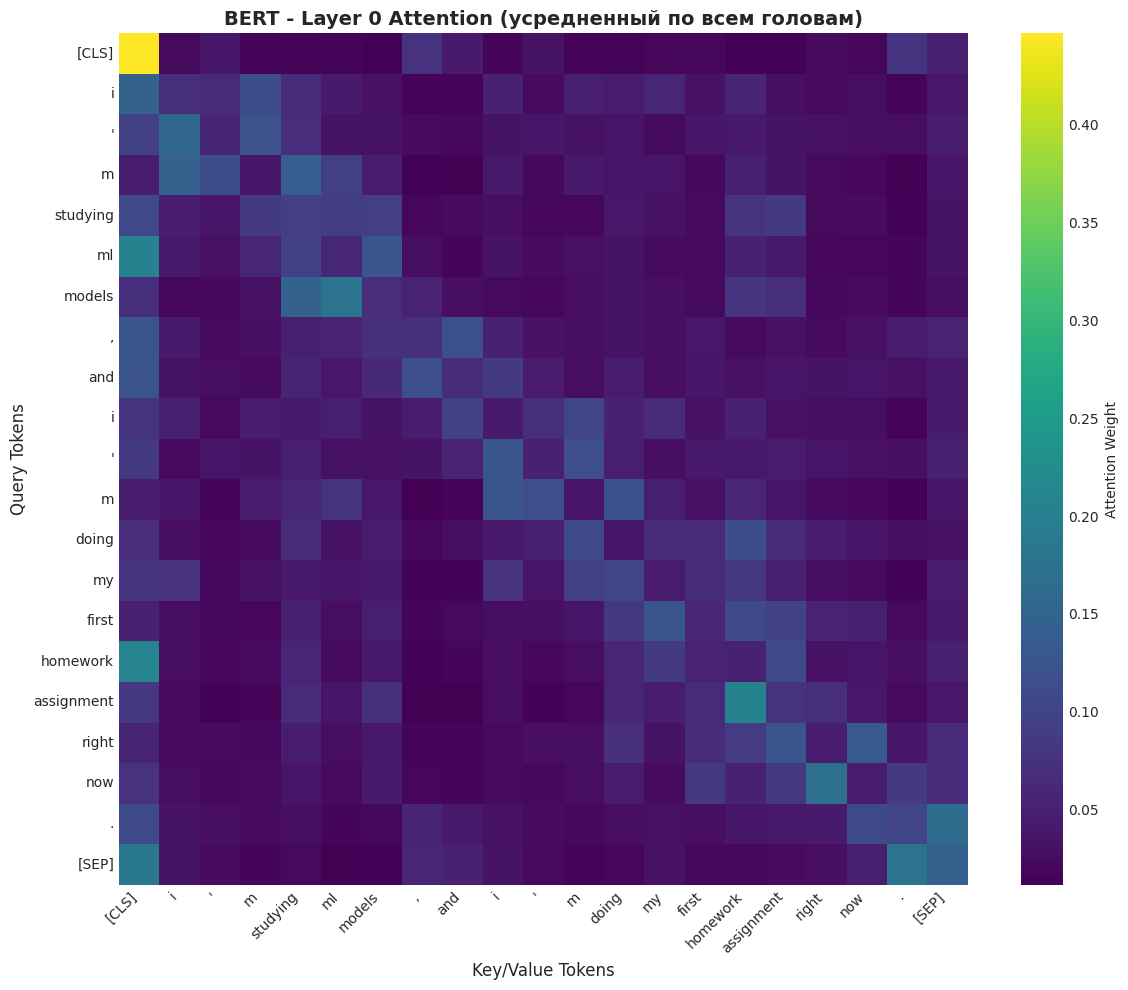


Основные наблюдения:
  - Максимальный вес внимания: 0.4469
  - Минимальный вес внимания: 0.0115
  - Средний вес внимания: 0.0476


In [25]:
# Визуализация BERT Layer 0
fig = plot_attention_heatmap(
    bert_layer_0,
    bert_result['tokens'],
    title="BERT - Layer 0 Attention (усредненный по всем головам)",
    figsize=(12, 10)
)
plt.show()

print("\nОсновные наблюдения:")
print(f"  - Максимальный вес внимания: {bert_layer_0.max():.4f}")
print(f"  - Минимальный вес внимания: {bert_layer_0.min():.4f}")
print(f"  - Средний вес внимания: {bert_layer_0.mean():.4f}")

In [26]:
# Извлечение attention для GPT-2
gpt2_result = gpt2_extractor.get_attention_weights(test_text)
gpt2_layer_0 = gpt2_extractor.get_layer_attention(test_text, layer_idx=0)

print(f"GPT-2 Analysis:")
print(f"  Количество слоев: {len(gpt2_result['attention'])}")
print(f"  Количество голов в слое: {gpt2_result['attention'][0].shape[1]}")
print(f"  Длина последовательности: {gpt2_layer_0.shape[0]}")
print(f"  Токены: {gpt2_result['tokens']}")

GPT-2 Analysis:
  Количество слоев: 12
  Количество голов в слое: 12
  Длина последовательности: 17
  Токены: ['I', "'m", 'Ġstudying', 'ĠML', 'Ġmodels', ',', 'Ġand', 'ĠI', "'m", 'Ġdoing', 'Ġmy', 'Ġfirst', 'Ġhomework', 'Ġassignment', 'Ġright', 'Ġnow', '.']


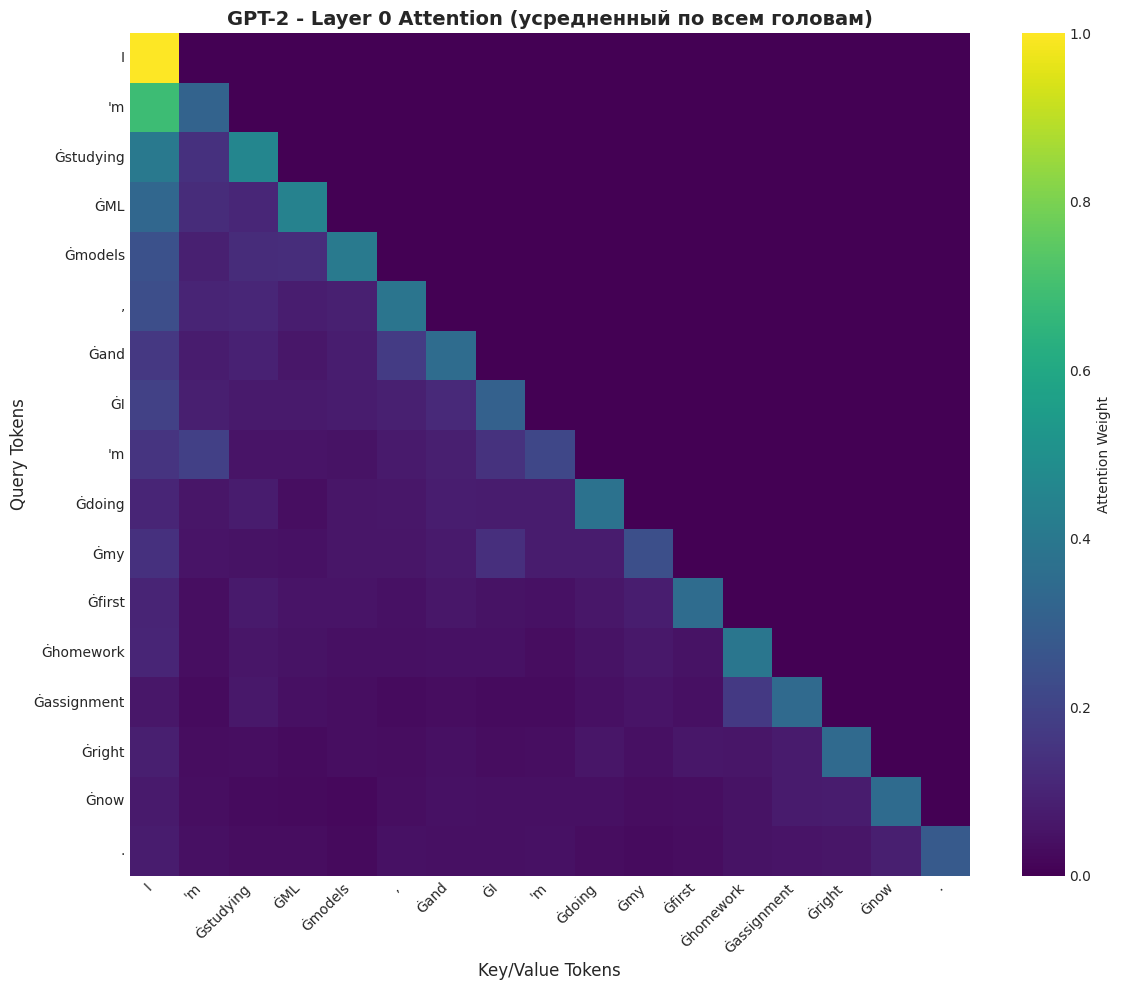


Основные наблюдения:
  - Максимальный вес внимания: 1.0000
  - Минимальный вес внимания: 0.0000
  - Средний вес внимания: 0.0588


In [27]:
# Визуализация GPT-2 Layer 0
fig = plot_attention_heatmap(
    gpt2_layer_0,
    gpt2_result['tokens'],
    title="GPT-2 - Layer 0 Attention (усредненный по всем головам)",
    figsize=(12, 10)
)
plt.show()

print("\nОсновные наблюдения:")
print(f"  - Максимальный вес внимания: {gpt2_layer_0.max():.4f}")
print(f"  - Минимальный вес внимания: {gpt2_layer_0.min():.4f}")
print(f"  - Средний вес внимания: {gpt2_layer_0.mean():.4f}")

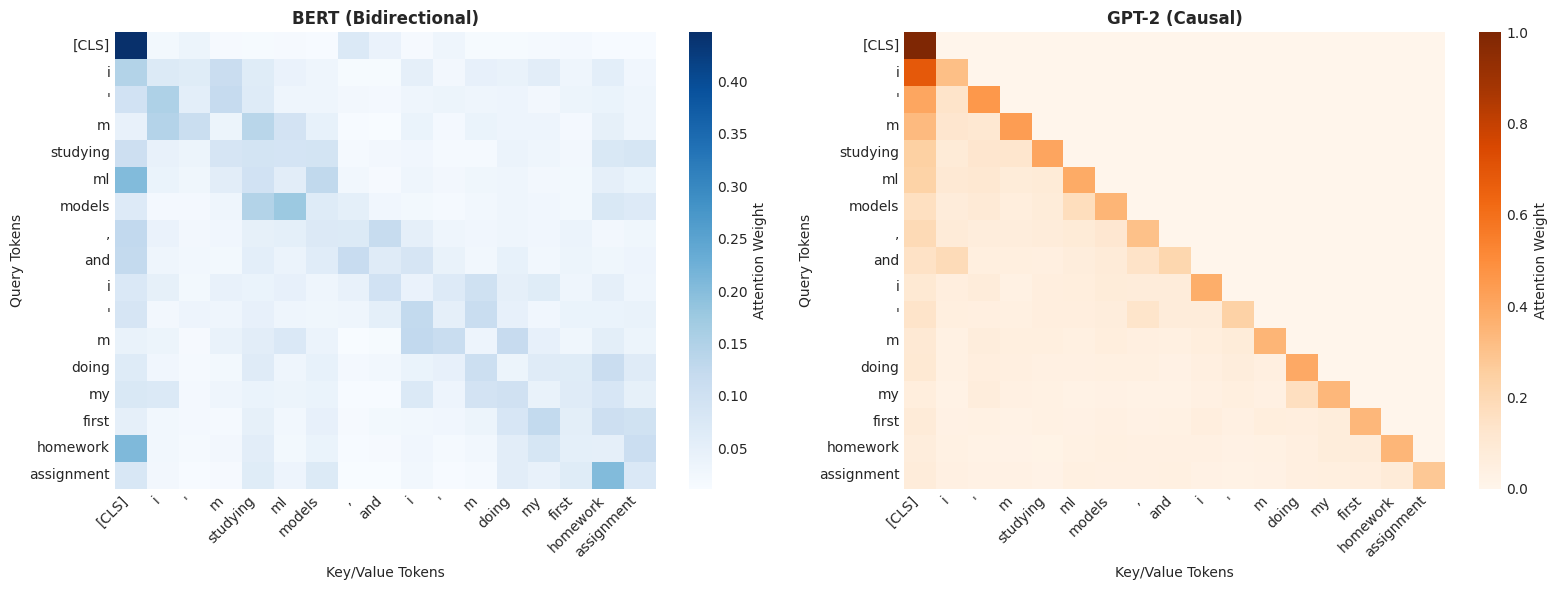

In [28]:
# Сравнение BERT и GPT-2
# Выровняем последовательности
min_len = min(bert_layer_0.shape[0], gpt2_layer_0.shape[0])
bert_truncated = bert_layer_0[:min_len, :min_len]
gpt2_truncated = gpt2_layer_0[:min_len, :min_len]
common_tokens = bert_result['tokens'][:min_len]

fig = compare_attention_patterns(
    bert_truncated,
    gpt2_truncated,
    common_tokens,
    figsize=(16, 6)
)
plt.show()

### 1.3 Анализ различий архитектур

In [29]:
# Анализ causal маски в GPT-2
print("АНАЛИЗ: Различия между BERT (bidirectional) и GPT-2 (causal)\n")
print("=" * 70)

# Проверим causal структуру в GPT-2
is_causal = np.triu(np.ones_like(gpt2_truncated), k=1) == 0
respects_causal_mask = np.allclose(gpt2_truncated[~is_causal], 0, atol=0.01)

print("\n1. СТРУКТУРА ATTENTION:")
print(f"\n   BERT (Bidirectional):")
print(f"   - Каждый токен может смотреть на все токены (слева и справа)")
print(f"   - Симметричная матрица внимания")
print(f"   - Используется при обучении на обе стороны контекста")

print(f"\n   GPT-2 (Causal/Autoregressive):")
print(f"   - Каждый токен может смотреть только на предыдущие токены")
print(f"   - Применяется causal mask (верхний треугольник = 0)")
print(f"   - Используется для авторегрессивной генерации")
print(f"   - Соответствует causal маске: {respects_causal_mask}")

print(f"\n2. ВИЗУАЛЬНЫЕ ОТЛИЧИЯ:")
print(f"   BERT: Полная матрица внимания")
print(f"   GPT-2: Нижнетреугольная матрица (верхний треугольник обнулен)")

print(f"\n3. ПРАКТИЧЕСКИЕ ПОСЛЕДСТВИЯ:")
print(f"   BERT: Лучше для задач понимания (классификация, NER)")
print(f"   GPT-2: Лучше для генерации текста")

print("\n" + "=" * 70)

АНАЛИЗ: Различия между BERT (bidirectional) и GPT-2 (causal)


1. СТРУКТУРА ATTENTION:

   BERT (Bidirectional):
   - Каждый токен может смотреть на все токены (слева и справа)
   - Симметричная матрица внимания
   - Используется при обучении на обе стороны контекста

   GPT-2 (Causal/Autoregressive):
   - Каждый токен может смотреть только на предыдущие токены
   - Применяется causal mask (верхний треугольник = 0)
   - Используется для авторегрессивной генерации
   - Соответствует causal маске: True

2. ВИЗУАЛЬНЫЕ ОТЛИЧИЯ:
   BERT: Полная матрица внимания
   GPT-2: Нижнетреугольная матрица (верхний треугольник обнулен)

3. ПРАКТИЧЕСКИЕ ПОСЛЕДСТВИЯ:
   BERT: Лучше для задач понимания (классификация, NER)
   GPT-2: Лучше для генерации текста




АНАЛИЗ: Изменение attention весов через слои



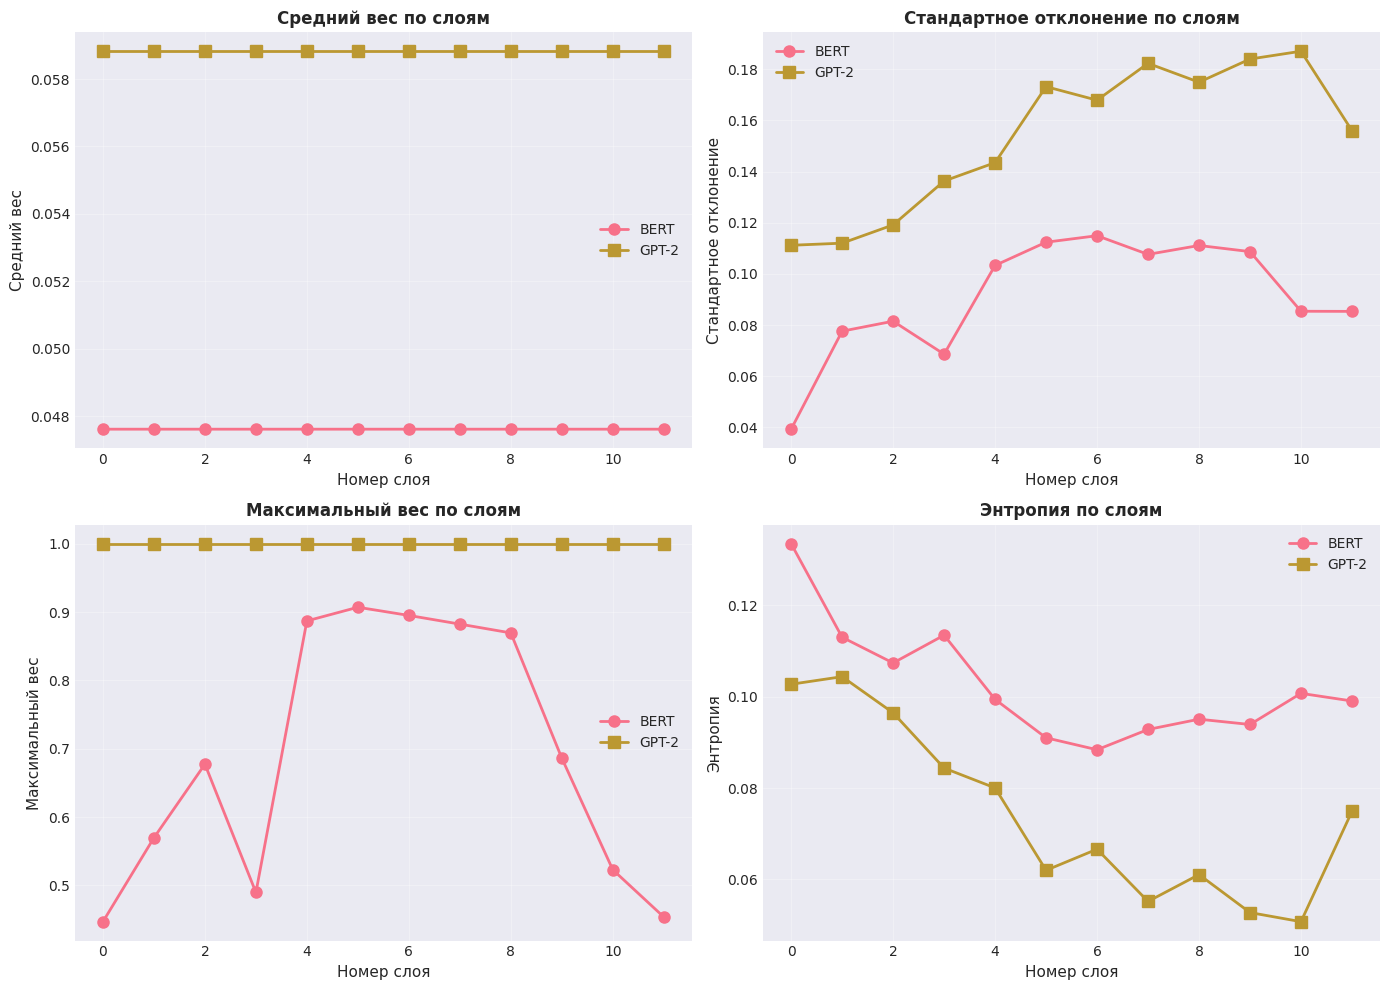


Основные выводы:
- Attention веса эволюционируют через слои сети
- Ранние слои обычно имеют более размытое внимание (высокая энтропия)
- Глубокие слои часто фокусируют внимание на специфических токенах
- Различия между архитектурами видны в паттернах эволюции



In [30]:
# Анализ изменения attention через слои
print("\nАНАЛИЗ: Изменение attention весов через слои\n")
print("=" * 70)

bert_layer_stats = []
gpt2_layer_stats = []

for layer_idx in range(len(bert_result['attention'])):
    bert_layer = bert_extractor.get_layer_attention(test_text, layer_idx=layer_idx)
    bert_layer_stats.append({
        'mean': bert_layer.mean(),
        'std': bert_layer.std(),
        'max': bert_layer.max(),
        'entropy': -np.sum(bert_layer * np.log(bert_layer + 1e-10)) / bert_layer.size
    })

for layer_idx in range(len(gpt2_result['attention'])):
    gpt2_layer = gpt2_extractor.get_layer_attention(test_text, layer_idx=layer_idx)
    gpt2_layer_stats.append({
        'mean': gpt2_layer.mean(),
        'std': gpt2_layer.std(),
        'max': gpt2_layer.max(),
        'entropy': -np.sum(gpt2_layer * np.log(gpt2_layer + 1e-10)) / gpt2_layer.size
    })

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['mean', 'std', 'max', 'entropy']
titles = ['Средний вес', 'Стандартное отклонение', 'Максимальный вес', 'Энтропия']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    
    bert_values = [s[metric] for s in bert_layer_stats]
    gpt2_values = [s[metric] for s in gpt2_layer_stats]
    
    ax.plot(range(len(bert_values)), bert_values, 'o-', label='BERT', linewidth=2, markersize=8)
    ax.plot(range(len(gpt2_values)), gpt2_values, 's-', label='GPT-2', linewidth=2, markersize=8)
    
    ax.set_xlabel('Номер слоя', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title} по слоям', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nОсновные выводы:")
print("- Attention веса эволюционируют через слои сети")
print("- Ранние слои обычно имеют более размытое внимание (высокая энтропия)")
print("- Глубокие слои часто фокусируют внимание на специфических токенах")
print("- Различия между архитектурами видны в паттернах эволюции")

print("\n" + "=" * 70)

## Часть 2: Дополнительные задания (30% оценки)

### 2.1 Multi-Head Attention анализ

MULTI-HEAD ATTENTION АНАЛИЗ

BERT Layer 0:
  Количество голов: 12
  Размер матрицы внимания: 21 x 21


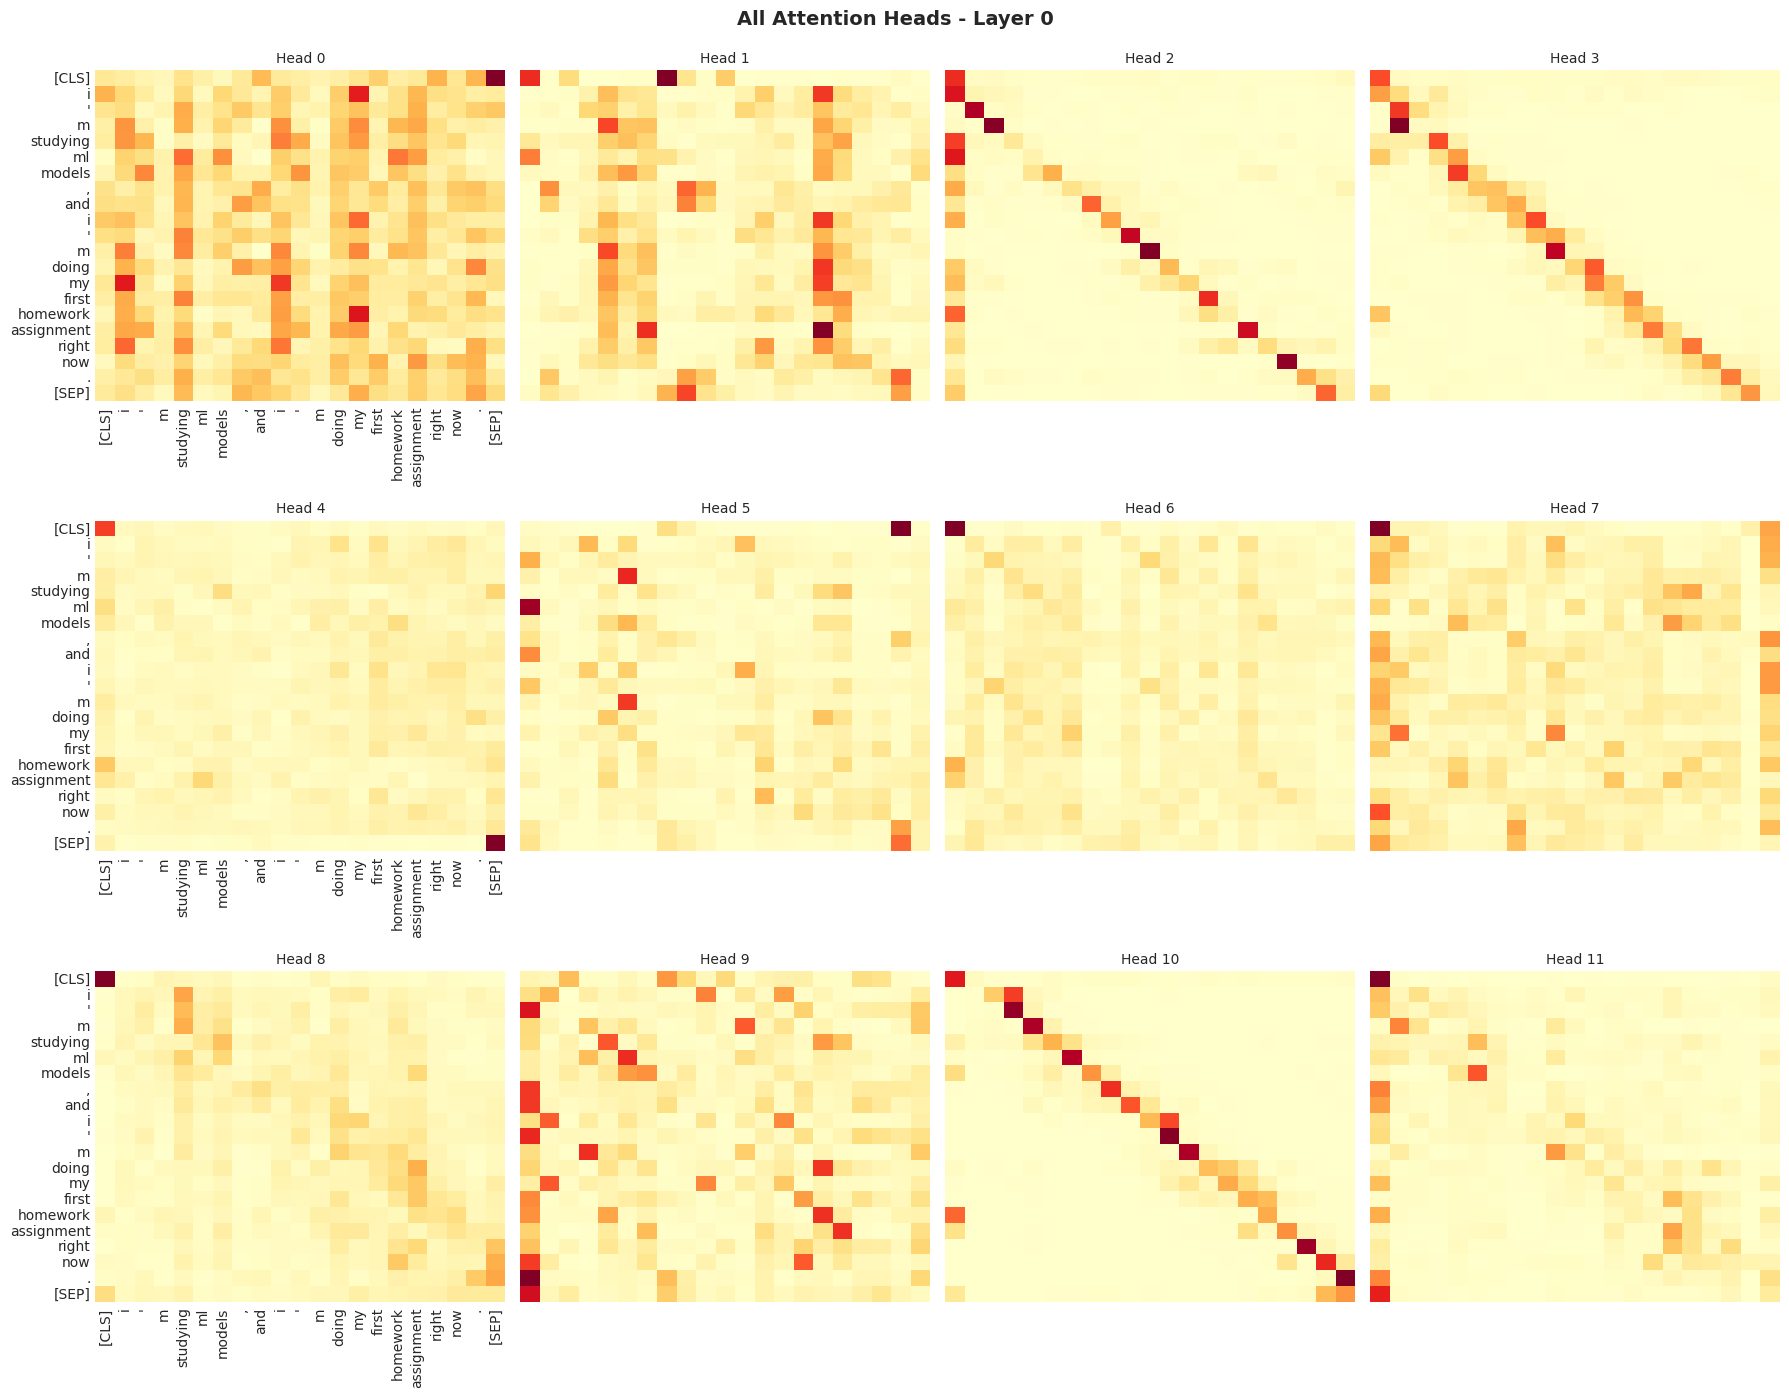

In [31]:
# Multi-Head Attention анализ для BERT
print("MULTI-HEAD ATTENTION АНАЛИЗ\n")
print("=" * 70)

# Получаем attention для всех голов
bert_heads, bert_tokens = bert_extractor.get_all_heads_attention(test_text, layer_idx=0)
min_len_heads = min(bert_heads.shape[1], bert_heads.shape[2])
bert_heads_truncated = bert_heads[:, :min_len_heads, :min_len_heads]

print(f"BERT Layer 0:")
print(f"  Количество голов: {bert_heads_truncated.shape[0]}")
print(f"  Размер матрицы внимания: {bert_heads_truncated.shape[1]} x {bert_heads_truncated.shape[2]}")

# Визуализация
fig = plot_all_heads(
    bert_heads_truncated,
    bert_tokens[:min_len_heads],
    layer_idx=0,
    figsize=(18, 14)
)
plt.show()

In [32]:
# Анализ специализации голов
print("\nСПЕЦИАЛИЗАЦИЯ ATTENTION ГОЛОВ\n")
print("=" * 70)

# Анализируем каждую голову
head_analysis = []
for head_idx in range(bert_heads_truncated.shape[0]):
    head = bert_heads_truncated[head_idx]
    
    # Диагональ (токен смотрит сам на себя)
    diagonal_attention = np.diag(head).mean()
    
    # Энтропия
    entropy = -np.sum(head * np.log(head + 1e-10)) / head.size
    
    # Специализация (отношение max к среднему)
    concentration = head.max() / head.mean()
    
    head_analysis.append({
        'head_id': head_idx,
        'diagonal': diagonal_attention,
        'entropy': entropy,
        'concentration': concentration
    })

# Вывод информации
print("\nХарактеристики каждой головы:\n")
print(f"{'Head':<6} {'Диагональ':<12} {'Энтропия':<12} {'Концентрация':<15} {'Тип':<20}")
print("-" * 70)

for analysis in head_analysis:
    head_id = analysis['head_id']
    diag = analysis['diagonal']
    ent = analysis['entropy']
    conc = analysis['concentration']
    
    # Классификация
    if conc > 3:  # Высокая концентрация
        head_type = "Специализированная"
    elif ent < 1.5:  # Низкая энтропия
        head_type = "Фокусированная"
    else:
        head_type = "Распределенная"
    
    print(f"{head_id:<6} {diag:<12.4f} {ent:<12.4f} {conc:<15.4f} {head_type:<20}")

print("\n" + "=" * 70)
print("\nИнтерпретация метрик:")
print("- Диагональ: Высокое значение = токен фокусируется на себе")
print("- Энтропия: Низкая = голова специализируется; Высокая = распределенное внимание")
print("- Концентрация: Высокая = голова сильно фокусируется; Низкая = равномерное внимание")


СПЕЦИАЛИЗАЦИЯ ATTENTION ГОЛОВ


Характеристики каждой головы:

Head   Диагональ    Энтропия     Концентрация    Тип                 
----------------------------------------------------------------------
0      0.0411       0.1387       4.0103          Специализированная  
1      0.0609       0.1172       8.1026          Специализированная  
2      0.0762       0.0681       19.5033         Специализированная  
3      0.0910       0.0769       18.6853         Специализированная  
4      0.0852       0.1335       14.1686         Специализированная  
5      0.0589       0.1155       14.3370         Специализированная  
6      0.1146       0.1320       14.2345         Специализированная  
7      0.0691       0.1263       9.5704          Специализированная  
8      0.0786       0.1284       12.6924         Специализированная  
9      0.1110       0.1188       8.4676          Специализированная  
10     0.0886       0.0586       19.4296         Специализированная  
11     0.0854       0.104

### 2.2 Кросс-языковое исследование

In [33]:
# Загрузка русскоязычной модели
print("Загрузка русскоязычной модели (RuBERT)...")

try:
    rubert_extractor = AttentionExtractor('DeepPavlov/rubert-base-cased', device=device)
    print("✓ RuBERT успешно загружен\n")
    rubert_available = True
except Exception as e:
    print(f"⚠ Не удалось загрузить RuBERT: {e}")
    print("Попытка загрузить альтернативную модель...")
    try:
        rubert_extractor = AttentionExtractor('bert-base-multilingual-cased', device=device)
        print("✓ Multilingual BERT загружен\n")
        rubert_available = True
    except:
        print("⚠ Не удалось загрузить русскоязычные модели")
        rubert_available = False

Загрузка русскоязычной модели (RuBERT)...


Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.transform.dense.weight', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.weight', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


✓ RuBERT успешно загружен



Русский текст: "Я изучаю ML модели, и сейчас выполняю свое первое домашнее задание"

Информация о модели:
  Количество слоев: 12
  Количество голов: 12
  Токены: ['[CLS]', 'Я', 'изуч', '##аю', 'ML', 'модели', ',', 'и', 'сейчас', 'выполня', '##ю', 'свое', 'первое', 'домашнее', 'задание', '[SEP]']



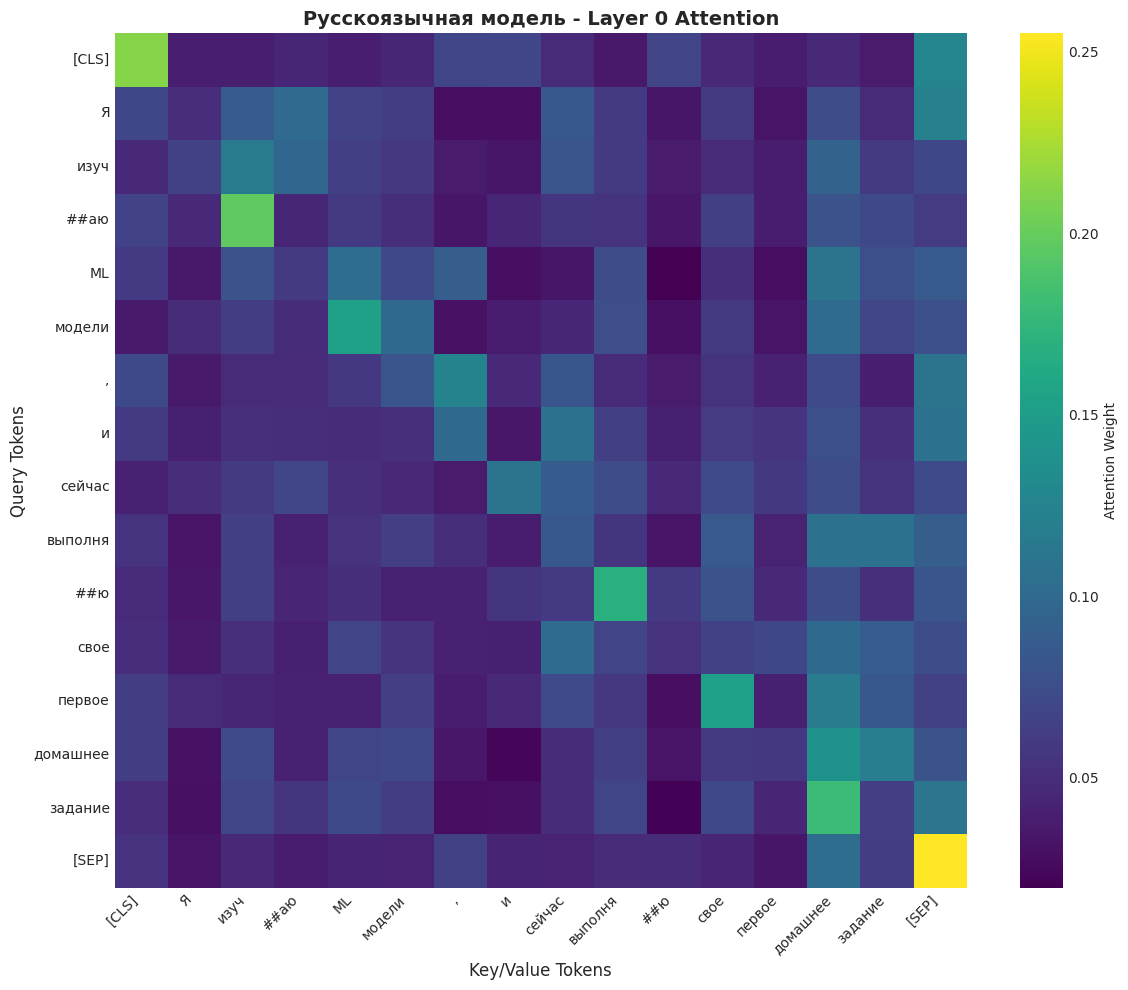

Статистика:
  Максимальный вес: 0.2550
  Минимальный вес: 0.0197
  Средний вес: 0.0625


In [34]:
if rubert_available:
    # Русский тестовый текст
    russian_text = "Я изучаю ML модели, и сейчас выполняю свое первое домашнее задание"
    
    print(f"Русский текст: \"{russian_text}\"\n")
    
    # Получение attention
    ru_result = rubert_extractor.get_attention_weights(russian_text)
    ru_layer_0 = rubert_extractor.get_layer_attention(russian_text, layer_idx=0)
    
    print(f"Информация о модели:")
    print(f"  Количество слоев: {len(ru_result['attention'])}")
    print(f"  Количество голов: {ru_result['attention'][0].shape[1]}")
    print(f"  Токены: {ru_result['tokens']}\n")
    
    # Визуализация
    fig = plot_attention_heatmap(
        ru_layer_0,
        ru_result['tokens'],
        title="Русскоязычная модель - Layer 0 Attention",
        figsize=(12, 10)
    )
    plt.show()
    
    print(f"Статистика:")
    print(f"  Максимальный вес: {ru_layer_0.max():.4f}")
    print(f"  Минимальный вес: {ru_layer_0.min():.4f}")
    print(f"  Средний вес: {ru_layer_0.mean():.4f}")


СРАВНЕНИЕ ATTENTION ПАТТЕРНОВ В РАЗНЫХ ЯЗЫКАХ



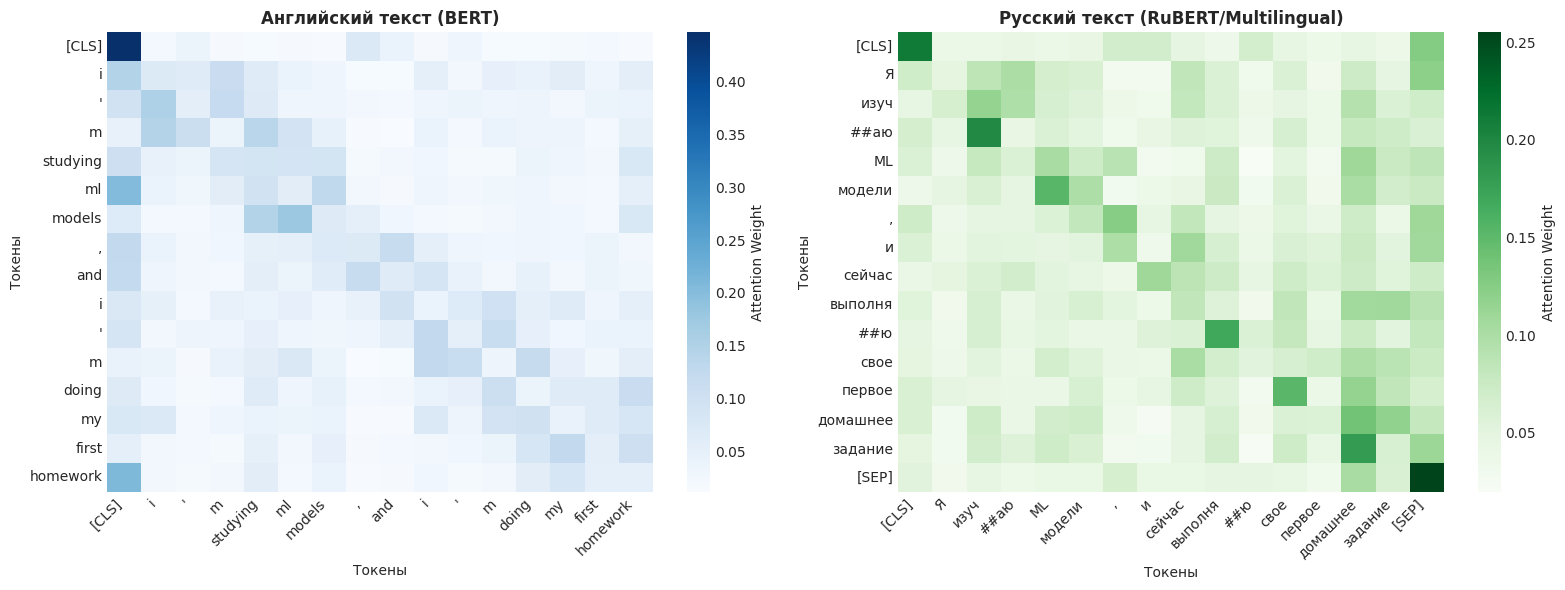


ОСОБЕННОСТИ ATTENTION В РАЗНЫХ ЯЗЫКАХ:

Английский текст:
  Средний вес: 0.0518
  Энтропия: 0.1408
  Спарсивность (% нулевых): 0.0%

Русский текст:
  Средний вес: 0.0625
  Энтропия: 0.1668
  Спарсивность (% нулевых): 0.0%



In [35]:
if rubert_available:
    # Сравнение английского и русского attention
    print("\nСРАВНЕНИЕ ATTENTION ПАТТЕРНОВ В РАЗНЫХ ЯЗЫКАХ\n")
    print("=" * 70)
    
    # Английский BERT
    en_result = bert_extractor.get_attention_weights(test_text)
    en_layer_0 = bert_extractor.get_layer_attention(test_text, layer_idx=0)
    
    # Выравнивание размеров для сравнения
    min_len_comparison = min(en_layer_0.shape[0], ru_layer_0.shape[0])
    en_truncated = en_layer_0[:min_len_comparison, :min_len_comparison]
    ru_truncated = ru_layer_0[:min_len_comparison, :min_len_comparison]
    
    en_tokens_trunc = en_result['tokens'][:min_len_comparison]
    ru_tokens_trunc = ru_result['tokens'][:min_len_comparison]
    
    # Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.heatmap(en_truncated, xticklabels=en_tokens_trunc, yticklabels=en_tokens_trunc,
                cmap='Blues', ax=axes[0], cbar_kws={'label': 'Attention Weight'})
    axes[0].set_title('Английский текст (BERT)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Токены')
    axes[0].set_ylabel('Токены')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
    
    sns.heatmap(ru_truncated, xticklabels=ru_tokens_trunc, yticklabels=ru_tokens_trunc,
                cmap='Greens', ax=axes[1], cbar_kws={'label': 'Attention Weight'})
    axes[1].set_title('Русский текст (RuBERT/Multilingual)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Токены')
    axes[1].set_ylabel('Токены')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    # Анализ
    print("\nОСОБЕННОСТИ ATTENTION В РАЗНЫХ ЯЗЫКАХ:\n")
    print(f"Английский текст:")
    print(f"  Средний вес: {en_truncated.mean():.4f}")
    print(f"  Энтропия: {-np.sum(en_truncated * np.log(en_truncated + 1e-10)) / en_truncated.size:.4f}")
    print(f"  Спарсивность (% нулевых): {np.sum(en_truncated < 0.01) / en_truncated.size * 100:.1f}%")
    
    print(f"\nРусский текст:")
    print(f"  Средний вес: {ru_truncated.mean():.4f}")
    print(f"  Энтропия: {-np.sum(ru_truncated * np.log(ru_truncated + 1e-10)) / ru_truncated.size:.4f}")
    print(f"  Спарсивность (% нулевых): {np.sum(ru_truncated < 0.01) / ru_truncated.size * 100:.1f}%")
    
    print("\n" + "=" * 70)
else:
    print("Русскоязычные модели недоступны. Пропускаем этот раздел.")